# Solar CARMA(4,3) order and ACF-based initialisation

Two real AR roots plus one fixed 24-hour complex-conjugate pair. Outputs are
versioned for CARMA(4,3) and do not overwrite the CARMA(5,4) calibration.


In [1]:
a=1

In [2]:
%matplotlib inline

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.linalg import expm, solve_continuous_lyapunov

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "solar" / "Intensity_Model_solar" / "intensity_calibration_solar.py").exists():
    REPO = CWD
    CODE = CWD / "solar" / "Intensity_Model_solar"
elif (CWD / "intensity_calibration_solar.py").exists():
    CODE = CWD
    REPO = CWD.parents[1]
else:
    raise FileNotFoundError("Run this notebook from the repo root or from solar/Intensity_Model_solar/.")

if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

from intensity_calibration_solar import run_intensity_model_calibration_solar

DATA = CODE / "data" / "carma"
OUT = DATA
FIG = CODE / "figures" / "carma"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)


def first_existing(candidates, label):
    for path in candidates:
        p = Path(path)
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {label}. Checked: " + ", ".join(str(Path(p)) for p in candidates))


spot_path = first_existing([
    REPO / "Vb-Academy PPAs Application" / "DayAheadPrices_2021_2025.csv",
    REPO / "DayAheadPrices_2021_2025.csv",
    REPO / "wind" / "Gabriel" / "DayAheadPrices_2021_2025.csv",
], "German day-ahead price CSV")

solar_path = first_existing([
    REPO / "enwex_GER_solar_v25_combined.csv",
    REPO / "wind" / "Gabriel" / "enwex_GER_solar_v25_combined.csv",
], "German solar capacity-factor CSV")

workspace = run_intensity_model_calibration_solar(
    spot_path=str(spot_path),
    solar_path=str(solar_path),
)

solar_variant = workspace.solar_variants["solar_clearsky"]
solar_fit = solar_variant.seasonality
transform = solar_fit.transform_params
if transform is None:
    raise RuntimeError("solar_clearsky seasonality has no transform parameters.")

solar_panel = pd.DataFrame({
    "solar_cf": solar_fit.physical_series,
    "solar_clear_sky": solar_fit.clear_sky_proxy,
    "solar_risk_driver": solar_fit.risk_driver,
    "solar_xprime": solar_fit.normalized_driver,
    "solar_latent_Y": solar_fit.series,
    "solar_latent_seasonality": solar_fit.fitted,
    "solar_XtQ": solar_fit.residual,
}).dropna()

panel_path = OUT / "solar_latent_panel.csv"
solar_panel.to_csv(panel_path)

metadata = {
    "source": "solar/Intensity_Model_solar/04order_solar.ipynb",
    "spot_path": str(spot_path),
    "solar_path": str(solar_path),
    "series": "solar_XtQ = solar_latent_Y - solar_latent_seasonality",
    "transform": {
        "alpha": float(transform.alpha),
        "beta": float(transform.beta),
        "epsilon": float(transform.epsilon),
        "clear_sky_floor": float(transform.clear_sky_floor),
        "clear_sky_quantile": float(transform.clear_sky_quantile),
        "clear_sky_smoothing_days": int(transform.clear_sky_smoothing_days),
    },
}
metadata_path = OUT / "solar_latent_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

pr = solar_panel["solar_XtQ"].to_numpy(float)
pr = pr[np.isfinite(pr)]
pr = pr - pr.mean()
N = len(pr)
v0 = float(pr @ pr / N)


def acf(k):
    k = int(k)
    return 1.0 if k == 0 else float(pr[:-k] @ pr[k:] / ((N - k) * v0))


def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()


print(f"{N:,} hourly solar latent residuals XtQ")
print(f"variance target v0 = {v0:.6e}")
print(f"panel saved: {panel_path}")
print(f"metadata saved: {metadata_path}")


C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\intensity_ar_solar.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(A, dtype=float)
C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\intensity_ar_solar.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(A, dtype=float)


40,627 hourly solar latent residuals XtQ
variance target v0 = 7.028301e+00
panel saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\data\carma\solar_latent_panel.csv
metadata saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\data\carma\solar_latent_metadata.json


Manual half-life bounds used by the optimizer:


,lower_h,upper_h,lower_d,upper_d
component,,,,
real_fast,0.40,48.00,0.02,2.00
real_mid,10.00,1200.00,0.42,50.00
osc_daily,12.00,4320.00,0.50,180.00


ACF calibration lags: 350
  short dense lags: 1..336 h
  long anchors h: [384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520, 2880, 3600, 4320]
  plot window: 0..500 h
Best half-lives h [real fast, real mid, osc daily]: [ 0.506 41.693 70.407]
Best half-lives d [real fast, real mid, osc daily]: [0.021 1.737 2.934]
Optimizer status: 4 Both `ftol` and `xtol` termination conditions are satisfied.


component,best_h,best_d,lower_h,upper_h,at_lower,at_upper
real_fast,0.51,0.02,0.40,48.00,False,False
real_mid,41.69,1.74,10.00,1200.00,False,False
osc_daily,70.41,2.93,12.00,4320.00,False,False


component,kind,half_life_h,half_life_d,period_h,share
real_fast,real,0.51,0.02,inf,0.459
real_mid,real,41.69,1.74,inf,0.305
osc_daily,osc,70.41,2.93,24.0,0.236


RMSE=0.047450  WSSR=1.0004  (CARMA order 4)


lag_h,empirical,model,err
1,0.6421,0.6421,-0.0000
2,0.5260,0.5248,-0.0012
3,0.4624,0.4595,-0.0029
6,0.2516,0.2760,+0.0245
12,0.0889,0.0401,-0.0488
18,0.1890,0.2260,+0.0371
24,0.5569,0.3908,-0.1661
30,0.1378,0.1851,+0.0473
48,0.3870,0.2843,-0.1027
72,0.2891,0.2082,-0.0809


Long-lag anchors included in calibration.


lag_h,days,empirical,model,err
384,16.0,0.0841,0.0059,-0.0782
432,18.0,0.0445,0.0036,-0.0409
504,21.0,0.0121,0.0017,-0.0104
600,25.0,-0.0346,0.0007,+0.0353
720,30.0,-0.0373,0.0002,+0.0375
960,40.0,-0.0440,0.0000,+0.0441
1200,50.0,-0.0565,0.0000,+0.0565
1440,60.0,-0.0631,0.0000,+0.0631
1800,75.0,-0.0690,0.0000,+0.0690
2160,90.0,0.0144,0.0000,-0.0144


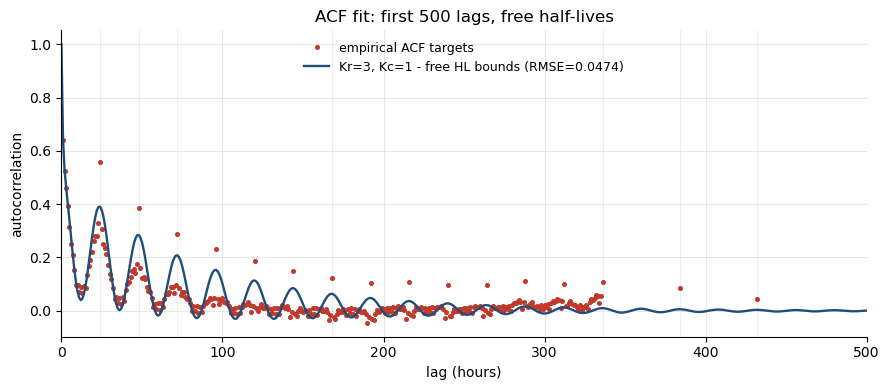

In [4]:
# ACF fit: Kr=3, Kc=1, fixed 24h period, free half-lives
Kr, Kc = 2, 1
m = Kr + Kc
n_hl = Kr + Kc
component_labels = np.array(["real_fast", "real_mid", "osc_daily"])
om_c_fixed = np.array([2 * np.pi / 24.0])

# Manual knobs. Edit these bounds before running the cell if the ACF fit
# pushes a mode to an implausible time scale.
ACF_PLOT_MAX_LAG_H = 500
HALF_LIFE_BOUNDS_H = pd.DataFrame({
    "component": component_labels,
    "lower_h": [0.4, 10.0, 12.0],
    "upper_h": [48, 50 * 24.0, 180.0 * 24.0],
}).set_index("component")

hl_lower_h = HALF_LIFE_BOUNDS_H.loc[component_labels, "lower_h"].to_numpy(float)
hl_upper_h = HALF_LIFE_BOUNDS_H.loc[component_labels, "upper_h"].to_numpy(float)
if np.any(hl_lower_h <= 0.0) or np.any(hl_upper_h <= hl_lower_h):
    raise ValueError("Half-life bounds must satisfy 0 < lower_h < upper_h for every component.")

bounds_display = HALF_LIFE_BOUNDS_H.copy()
bounds_display["lower_d"] = bounds_display["lower_h"] / 24.0
bounds_display["upper_d"] = bounds_display["upper_h"] / 24.0
print("Manual half-life bounds used by the optimizer:")
display(bounds_display.style.format({
    "lower_h": "{:.2f}",
    "upper_h": "{:.2f}",
    "lower_d": "{:.2f}",
    "upper_d": "{:.2f}",
}))

# Calibration target: dense hourly short lags + sparse long anchors.
short_lags = np.arange(1, 337)
long_anchor_lags = np.array([
    384,   # 16d
    432,   # 18d
    504,   # 21d
    600,   # 25d
    720,   # 30d
    960,   # 40d
    1200,  # 50d
    1440,  # 60d
    1800,  # 75d
    2160,  # 90d
    2520,  # 105d
    2880,  # 120d
    3600,  # 150d
    4320,  # 180d
])

lags_fit = np.concatenate([short_lags, long_anchor_lags])
rho_emp_fit = np.array([acf(k) for k in lags_fit])

wts_fit = 1.0 / np.sqrt(lags_fit.astype(float))
wts_fit[lags_fit <= 72] *= 2.0
wts_fit[lags_fit >= 168] *= 2.0
wts_fit[lags_fit >= 720] *= 1.5
wts_fit[lags_fit >= 2160] *= 2.0

for anchor in [1, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336]:
    wts_fit[lags_fit == anchor] *= 8.0

for anchor in [720, 1440, 2160, 2880, 3600, 4320]:
    wts_fit[lags_fit == anchor] *= 10.0

sw_fit = np.sqrt(wts_fit / wts_fit.mean())

lags = lags_fit
rho_emp = rho_emp_fit
sw = sw_fit

def unpack_theta(theta):
    # theta = [log_hl_real_0..2, log_hl_osc, share_logits_0..3]
    theta = np.asarray(theta, dtype=float)

    hl_all = np.exp(theta[:n_hl])
    hl_real = hl_all[:Kr]
    hl_osc = hl_all[Kr:Kr + Kc]

    kap_real = np.log(2.0) / hl_real
    kap_osc = np.log(2.0) / hl_osc
    sh = softmax(theta[n_hl:n_hl + m])

    return hl_real, hl_osc, kap_real, kap_osc, sh

def rho_24(theta, k):
    hl_real, hl_osc, kap_real, kap_osc, sh = unpack_theta(theta)
    h = np.asarray(k, dtype=float)

    out = np.zeros_like(h, dtype=float)
    for i in range(Kr):
        out += sh[i] * np.exp(-kap_real[i] * h)
    for j in range(Kc):
        idx = Kr + j
        out += sh[idx] * np.exp(-kap_osc[j] * h) * np.cos(om_c_fixed[j] * h)
    return out

lb = np.r_[np.log(hl_lower_h), [-9.0] * m]
ub = np.r_[np.log(hl_upper_h), [9.0] * m]

start_hl = np.array([
    [2.0, 24.0, 72.0],
    [4.0, 36.0, 96.0],
    [1.0, 12.0, 48.0],
    [6.0, 48.0, 120.0],
    [3.0, 72.0, 96.0],
    [8.0, 120.0, 96.0],
    [10.0, 160.0, 168.0],
], dtype=float)

if start_hl.shape[1] != n_hl:
    raise ValueError(f"start_hl must have {n_hl} columns: {component_labels.tolist()}")
start_hl = np.clip(start_hl, hl_lower_h, hl_upper_h)

rng = np.random.default_rng(42)
best = None
n_starts = 80

print(f"ACF calibration lags: {len(lags_fit)}")
print(f"  short dense lags: {short_lags[0]}..{short_lags[-1]} h")
print(f"  long anchors h: {long_anchor_lags.tolist()}")
print(f"  plot window: 0..{ACF_PLOT_MAX_LAG_H} h")

for s in range(n_starts):
    if s < len(start_hl):
        xs = np.r_[np.log(start_hl[s]), [0.0] * m]
    else:
        xs = np.r_[np.log(start_hl[s % len(start_hl)]), [0.0] * m]
        xs[:n_hl] += rng.normal(0, 0.65, n_hl)
        xs[n_hl:n_hl + m] += rng.normal(0, 1.2, m)

    xs = np.clip(xs, lb, ub)

    r = least_squares(
        lambda t: sw_fit * (rho_24(t, lags_fit) - rho_emp_fit),
        xs,
        bounds=(lb, ub),
        max_nfev=9000,
    )
    if best is None or r.cost < best.cost:
        best = r

hl_real_b, hl_osc_b, kap_r, kap_c, sh_b = unpack_theta(best.x)
kap_b = np.r_[kap_r, kap_c]
hl_best = np.r_[hl_real_b, hl_osc_b]

active_lower = np.isclose(hl_best, hl_lower_h, rtol=1e-5, atol=1e-6)
active_upper = np.isclose(hl_best, hl_upper_h, rtol=1e-5, atol=1e-6)
bounds_report = pd.DataFrame({
    "component": component_labels,
    "best_h": hl_best,
    "best_d": hl_best / 24.0,
    "lower_h": hl_lower_h,
    "upper_h": hl_upper_h,
    "at_lower": active_lower,
    "at_upper": active_upper,
})

print("Best half-lives h [real fast, real mid, osc daily]:", np.round(hl_best, 3))
print("Best half-lives d [real fast, real mid, osc daily]:", np.round(hl_best / 24.0, 3))
print("Optimizer status:", best.status, best.message)
display(bounds_report.style.format({
    "best_h": "{:.2f}",
    "best_d": "{:.2f}",
    "lower_h": "{:.2f}",
    "upper_h": "{:.2f}",
}).hide(axis="index"))

rows = []
for i in range(Kr):
    hl_h = hl_real_b[i]
    rows.append({
        "component": component_labels[i],
        "kind": "real",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": np.inf,
        "share": sh_b[i],
    })
for j in range(Kc):
    idx = Kr + j
    hl_h = hl_osc_b[j]
    rows.append({
        "component": component_labels[idx],
        "kind": "osc",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": 24.0,
        "share": sh_b[idx],
    })

summary_24 = pd.DataFrame(rows)
display(summary_24.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags_fit) - rho_emp_fit) ** 2)))
wssr_24 = float(np.sum((sw_fit * (rho_24(best.x, lags_fit) - rho_emp_fit)) ** 2))
print(f"RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr + 2 * Kc})")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "model": rho_24(best.x, np.array(diag, dtype=float)),
})
cmp["err"] = cmp["model"] - cmp["empirical"]
display(cmp.style.format({
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

diag_long = list(long_anchor_lags)
cmp_long = pd.DataFrame({
    "lag_h": diag_long,
    "days": np.array(diag_long) / 24.0,
    "empirical": [acf(k) for k in diag_long],
    "model": rho_24(best.x, np.array(diag_long, dtype=float)),
})
cmp_long["err"] = cmp_long["model"] - cmp_long["empirical"]

print("Long-lag anchors included in calibration.")
display(cmp_long.style.format({
    "days": "{:.1f}",
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

plot_mask = lags_fit <= ACF_PLOT_MAX_LAG_H
kk = np.arange(0, ACF_PLOT_MAX_LAG_H + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags_fit[plot_mask], rho_emp_fit[plot_mask], "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, rho_24(best.x, kk), "-", lw=1.7, color="#1f4e79",
        label=f"Kr=3, Kc=1 - free HL bounds (RMSE={rmse_24:.4f})")

for d in [24, 48, 72, 168, 336, 384, 432]:
    if d <= ACF_PLOT_MAX_LAG_H:
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, ACF_PLOT_MAX_LAG_H)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF fit: first 500 lags, free half-lives")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


P(u) degree=3  leading=8.9532e+00  (expected 2v0*sum(kappa*w)=8.9532e+00)
All b roots Re<0: True  |  max Re=-5.50e-02
b = [0.008477, 0.083612, 0.230583, 1.      ]
b^T*P_norm*b = 7.8500e-01  (v0=7.0283e+00)

=== ACF verification ===
  Multiscale model  RMSE=0.047450  WSSR=1.0004
  Spectral b        RMSE=0.047450  WSSR=1.0004
  delta RMSE = 4.17e-15  (should be near 0)


lag_h,empirical,multiscale,"CARMA(4,3) sf-b",err_sf
1,0.6421,0.6421,0.6421,-0.0000
2,0.5260,0.5248,0.5248,-0.0012
3,0.4624,0.4595,0.4595,-0.0029
6,0.2516,0.2760,0.2760,0.0245
12,0.0889,0.0401,0.0401,-0.0488
18,0.1890,0.2260,0.2260,0.0371
24,0.5569,0.3908,0.3908,-0.1661
30,0.1378,0.1851,0.1851,0.0473
48,0.3870,0.2843,0.2843,-0.1027
72,0.2891,0.2082,0.2082,-0.0809


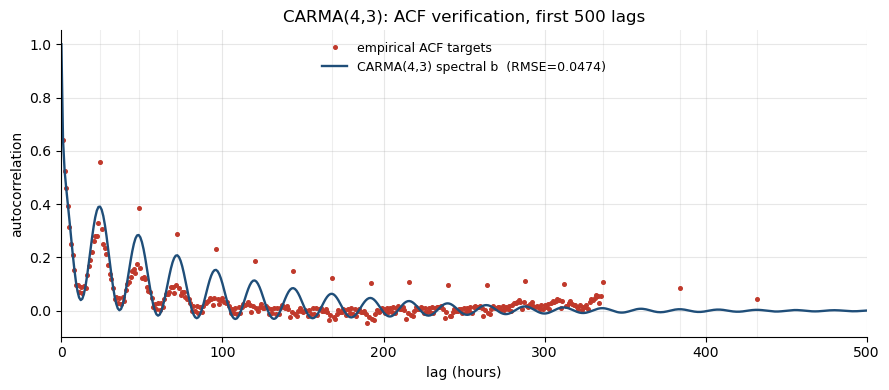

saved: solar_multiscale_carma43_selected.json
saved: solar_carma43_b_init.json
saved: solar_multiscale_carma43_selected_components.csv

=== Init for nb03: p=4, q=3 ===
  b = [0.008477, 0.083612, 0.230583, 1.      ]


In [5]:
# Spectral factorisation CARMA(4,3) + versioned export
kap_r = kap_b[:Kr]
sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]
sh_c = sh_b[Kr:]
om_c = om_c_fixed.copy()
p = Kr + 2 * Kc

roots_ar = [complex(-kap_r[i], 0.0) for i in range(Kr)]
for j in range(Kc):
    roots_ar.extend([
        complex(-kap_c[j], om_c[j]),
        complex(-kap_c[j], -om_c[j]),
    ])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p - 1):
    A[i, i + 1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p)
ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k: np.array([1.0, k ** 2])
fp_c2 = lambda k, o: np.array([1.0, 2 * (k ** 2 - o ** 2), (k ** 2 + o ** 2) ** 2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2 * kap_r[i] * sh_r[i] * v0])
    for i2 in range(Kr):
        if i2 != i:
            t = np.polymul(t, fr2[i2])
    for j in range(Kc):
        t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)

for j in range(Kc):
    t = np.polymul(
        np.array([2 * kap_c[j] * sh_c[j] * v0]),
        np.array([1.0, kap_c[j] ** 2 + om_c[j] ** 2]),
    )
    for i in range(Kr):
        t = np.polymul(t, fr2[i])
    for j2 in range(Kc):
        if j2 != j:
            t = np.polymul(t, fc2[j2])
    P_u = np.polyadd(P_u, t)

print(f"P(u) degree={len(P_u) - 1}  leading={P_u[0]:.4e}  "
      f"(expected 2v0*sum(kappa*w)={2 * v0 * float(np.r_[kap_r, kap_c] @ sh_b):.4e})")

u_roots = np.roots(P_u)
b_roots = np.array([
    1j * np.sqrt(uk) if np.real(1j * np.sqrt(uk)) < np.real(-1j * np.sqrt(uk))
    else -1j * np.sqrt(uk)
    for uk in u_roots
])
print(f"All b roots Re<0: {np.all(np.real(b_roots) < 0)}  |  max Re={np.max(np.real(b_roots)):.2e}")

b_vec_raw = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec_raw / b_vec_raw[-1]   # book convention: monic highest MA coefficient b_q = 1
Pb = P_norm @ b_vec
var0 = float(b_vec @ Pb)
print(f"b = {np.array2string(b_vec, precision=6, separator=', ')}")
print(f"b^T*P_norm*b = {var0:.4e}  (v0={v0:.4e})")

eAh = np.stack([expm(A * float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp) ** 2)))
wssr_sf = float(np.sum((sw * (rho_sf - rho_emp)) ** 2))
print("\n=== ACF verification ===")
print(f"  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}")
print(f"  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}")
print(f"  delta RMSE = {rmse_sf - rmse_24:.2e}  (should be near 0)")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
eAhd = np.stack([expm(A * float(h)) for h in diag])
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "multiscale": rho_24(best.x, np.array(diag, dtype=float)),
    f"CARMA({p},{p-1}) sf-b": (eAhd @ Pb) @ b_vec / var0,
})
cmp["err_sf"] = cmp[f"CARMA({p},{p-1}) sf-b"] - cmp["empirical"]
display(cmp.style.format({c: "{:.4f}" for c in cmp.columns[1:]}).hide(axis="index"))

plot_mask = lags_fit <= ACF_PLOT_MAX_LAG_H
kk = np.arange(0, ACF_PLOT_MAX_LAG_H + 1)
eAhp = np.stack([expm(A * float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags_fit[plot_mask], rho_emp[plot_mask], "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, (eAhp @ Pb) @ b_vec / var0, "-", lw=1.7, color="#1f4e79",
        label=f"CARMA({p},{p-1}) spectral b  (RMSE={rmse_sf:.4f})")
for d in [24, 48, 72, 168, 336, 384, 432]:
    if d <= ACF_PLOT_MAX_LAG_H:
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, ACF_PLOT_MAX_LAG_H)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title(f"CARMA({p},{p-1}): ACF verification, first 500 lags")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

def _ser(x):
    x = float(x)
    return None if not np.isfinite(x) else x

components = [
    {
        "component": str(r["component"]),
        "kind": str(r["kind"]),
        "half_life_h": float(r["half_life_h"]),
        "half_life_d": float(r["half_life_d"]),
        "period_h": _ser(r["period_h"]),
        "share": float(r["share"]),
    }
    for _, r in summary_24.iterrows()
]

half_life_bounds_h = {
    str(label): {
        "lower": float(HALF_LIFE_BOUNDS_H.loc[label, "lower_h"]),
        "upper": float(HALF_LIFE_BOUNDS_H.loc[label, "upper_h"]),
    }
    for label in component_labels
}
half_life_bounds_d = {
    str(label): {
        "lower": float(HALF_LIFE_BOUNDS_H.loc[label, "lower_h"] / 24.0),
        "upper": float(HALF_LIFE_BOUNDS_H.loc[label, "upper_h"] / 24.0),
    }
    for label in component_labels
}

payload = dict(
    selected=dict(Kr=Kr, Kc=Kc, order=p),
    roots=[[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients=[float(x) for x in ar],
    b_coefficients=[float(x) for x in b_vec],
    metrics=dict(
        rmse_multiscale=float(rmse_24),
        wssr_multiscale=float(wssr_24),
        rmse_spectral=float(rmse_sf),
        wssr_spectral=float(wssr_sf),
    ),
    components=components,
    calibration=dict(
        max_fit_lag_h=int(lags_fit.max()),
        max_fit_lag_d=float(lags_fit.max() / 24.0),
        dense_lag_max_h=int(short_lags.max()),
        dense_lag_max_d=float(short_lags.max() / 24.0),
        long_anchor_lags_h=[int(x) for x in long_anchor_lags],
        half_life_bounds_h=half_life_bounds_h,
        half_life_bounds_d=half_life_bounds_d,
        acf_plot_max_lag_h=int(ACF_PLOT_MAX_LAG_H),
        n_fit_lags=int(len(lags_fit)),
    ),
    note="Solar XtQ. Kr=2 Kc=1 period=24h fixed; all half-lives are optimised inside explicit manual bounds. CARMA(5,4). Monic b[-1]=1 (book convention).",
)
(OUT / "solar_multiscale_carma43_selected.json").write_text(json.dumps(payload, indent=2))
(OUT / "solar_carma43_b_init.json").write_text(json.dumps(dict(
    b_coefficients=[float(x) for x in b_vec],
    AR_order=int(p),
    MA_order=int(p - 1),
    acf_rmse_spectral=float(rmse_sf),
    acf_rmse_multiscale=float(rmse_24),
    note=f"CARMA({p},{p-1}) spectral b from ACF calibration with free half-lives and manual bounds. Monic b[-1]=1 (book convention).",
), indent=2))

summary_24.to_csv(OUT / "solar_multiscale_carma43_selected_components.csv", index=False)
print("saved: solar_multiscale_carma43_selected.json")
print("saved: solar_carma43_b_init.json")
print("saved: solar_multiscale_carma43_selected_components.csv")
print(f"\n=== Init for nb03: p={p}, q={p - 1} ===")
print(f"  b = {np.array2string(b_vec, precision=6, separator=', ')}")
